# Vector-borne disease

In [1]:
from pykappa import System
import matplotlib.pyplot as plt

The following model is adapted from ["Rule-based epidemic models"](https://doi.org/10.1016/j.jtbi.2021.110851) by Waites et al. We simulate a simple vector-borne disease which can travel between both mosquitoes (`V(x{s i})`) and hosts (`P(x{s e i r})`). The disease progresses: hosts are initially susceptible (`x{s}`) to the disease, later become exposed after coming in contact with a mosquito (`x{e}`), are infected (`x{i}`), and eventually recover (`x{r}`).

In [2]:
INIT_M = 5_000  # intial number of mosquitoes;
INIT_N = 1_000  # total host population, of which...
INIT_I = 10  # are initially infectious, and
INIT_S = INIT_N - INIT_I  # are initially susceptible

variables = {
    "beta": "0.036",  # probability of infection from a bite
    "bprime": "1",  # proabability of a vector becoming infectious
    "alpha": "0.2",  # progression from exposed to infectious
    "gamma": "0.1429",  # progression from infectious to removed
    "kappa": "1.0",  # bites per day per mosquito
    "kb": "0.1429",  # birth rate
    "kd": "0.1429",  # death rate
    "water": "1",  # amount of breeding habitat available
}

rules = [
    "P(x{e}) -> P(x{i}) @ 'alpha'",  # disease progression
    "P(x{i}) -> P(x{r}) @ 'gamma'",  # disease recovery
    "V(), . -> V(), V(x{s}) @ 'water' * 'kb'",  # vector birth
    "V()    -> .            @ 'kd'",  # vector annihilation
    # both hosts and vectors can be infected from a bite event
    "P(x{i}), V(x{s}) -> P(x{i}), V(x{i}) @ 'bprime' * 'kappa' / 'M'",
    "V(x{i}), P(x{s}) -> V(x{i}), P(x{e}) @ 'beta' * 'kappa' / 'N'",
]

observables = {
    "N": "|P()|",
    "S": "|P(x{s})|",
    "E": "|P(x{e})|",
    "I": "|P(x{i})|",
    "R": "|P(x{r})|",
    "M": "|V()|",
    "Vs": "|V(x{s})|",
    "Vi": "|V(x{i})|",
}

system = System.from_kappa(
    mixture={"P(x{i})": INIT_I, "P(x{s})": INIT_S, "V(x{s})": INIT_M},
    rules=rules,
    variables=variables,
    observables=observables,
    seed=42,
)

We run the simulation for 375 time units:

In [3]:
while system.time < 375:
    system.update()

We plot the numbers of hosts each disease progression state over time. The system eventually equilibriates; the disease is wiped out.

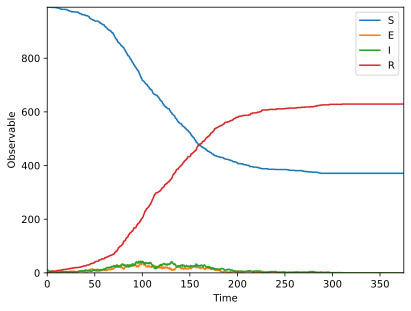

In [4]:
system.monitor.plot(combined=True, observables=["S", "E", "I", "R"])
plt.show()

All infected vectors eventually perish:

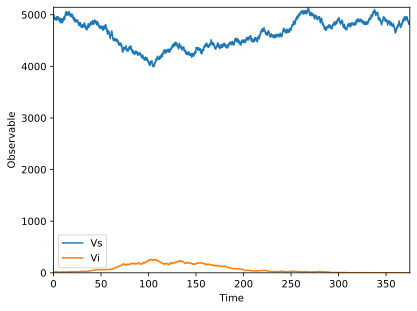

In [5]:
system.monitor.plot(combined=True, observables=["Vs", "Vi"])
plt.show()

Now we regenerate the system from scratch in order to demonstrate the impact of an environmental intervention.

In [6]:
system = System.from_kappa(
    mixture={"P(x{i})": INIT_I, "P(x{s})": INIT_S, "V(x{s})": INIT_M},
    rules=rules,
    variables=variables,
    observables=observables,
    seed=42,
)

Every sixty time units, we remove water from the environment, which slows the mosquito birth rate relative to the death rate.

In [7]:
update_after = 60.0
while system["M"] > 0:
    system.update()

    if system.time > update_after:
        update_after += 60.0
        system["water"] = system["water"] * 0.9

All mosquitoes eventually perish, and the disease is eliminated.

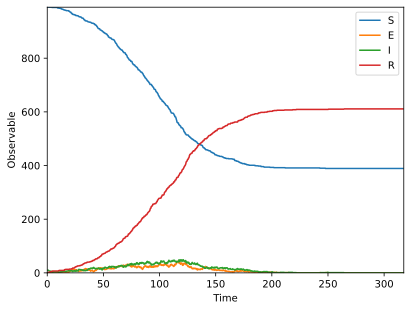

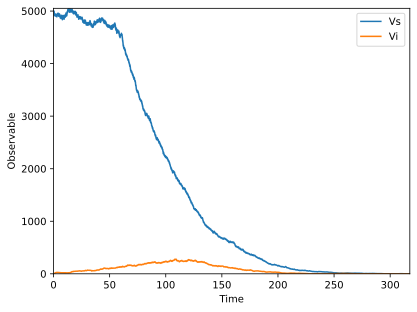

In [8]:
system.monitor.plot(combined=True, observables=["S", "E", "I", "R"])
system.monitor.plot(combined=True, observables=["Vs", "Vi"])
plt.show()